In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
run = "19-18-53"
# run = "18-43-26"
# run = "18-17-08"
with open(f"outputs/2025-07-09/{run}/logs.pkl", "rb") as f:
    logs = pickle.load(f)
sols = np.load(f"outputs/2025-07-09/{run}/solutions.npy")

In [13]:
logs.keys()

dict_keys(['fitnesses', 'fitness_mean', 'fitness_max', 'fitness_min', 'sigma_sq', 'objective', 'descriptors', 'avg_pairwise_distance'])

[61.44283676147461, 61.10441970825195, 58.89799118041992, 56.79427719116211, 54.044769287109375, 50.4691276550293, 46.50478744506836, 40.47053527832031, 32.00251388549805, 30.729461669921875]
[20.265037536621094, 20.26519775390625, 20.26535987854004, 20.265506744384766, 20.265653610229492, 20.26580047607422, 20.265939712524414, 20.26607322692871, 20.26620101928711, 20.266334533691406]


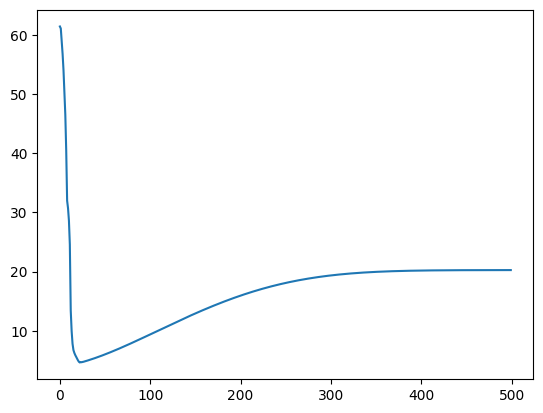

In [24]:
plt.plot(logs["avg_pairwise_distance"])
print(logs["avg_pairwise_distance"][:10])
print(logs["avg_pairwise_distance"][-10:])

(array([  3.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 125.]),
 array([-82.5506134 , -72.04180145, -61.5329895 , -51.02417755,
        -40.5153656 , -30.00655174, -19.49773788,  -8.98892593,
          1.51988602,  12.02869797,  22.53750992,  33.04632187,
         43.55513763,  54.06394958,  64.57276154,  75.08157349,
         85.59038544,  96.09919739, 106.60800934, 117.11682129,
        127.62563324, 138.13444519, 148.64326477, 159.15206909,
        169.66088867, 180.16969299, 190.67851257, 201.18731689,
        211.69613647, 222.2049408 , 232.71376038, 243.2225647 ,
        253.73138428]),
 <BarContainer object of 32 artists>)

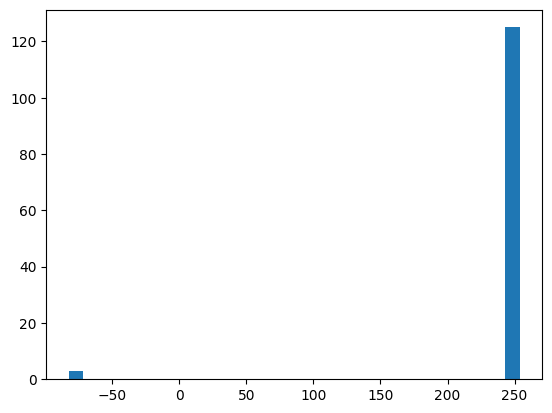

In [16]:
plt.hist(logs["descriptors"][-1][:, 0], bins=32)

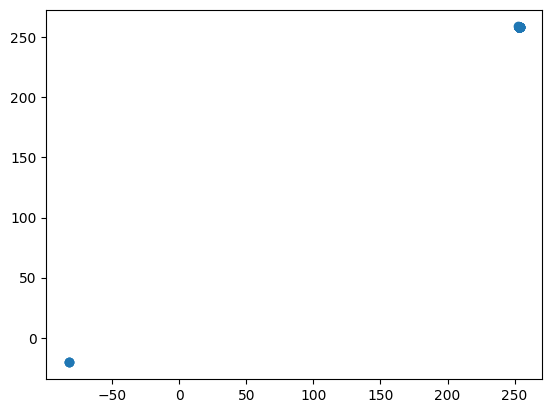

In [17]:
plt.scatter(logs["descriptors"][-1][:, 0], logs["descriptors"][-1][:, 1])

In [25]:
descs = logs["descriptors"][-1]
fits = logs["fitnesses"][-1]

Detected Outliers:
  - Index: 2, Fitness: 71.34, Behavior: [-82.54826 -20.55989]
  - Index: 90, Fitness: 71.44, Behavior: [-82.54944  -20.560875]
  - Index: 94, Fitness: 71.54, Behavior: [-82.55061 -20.56192]


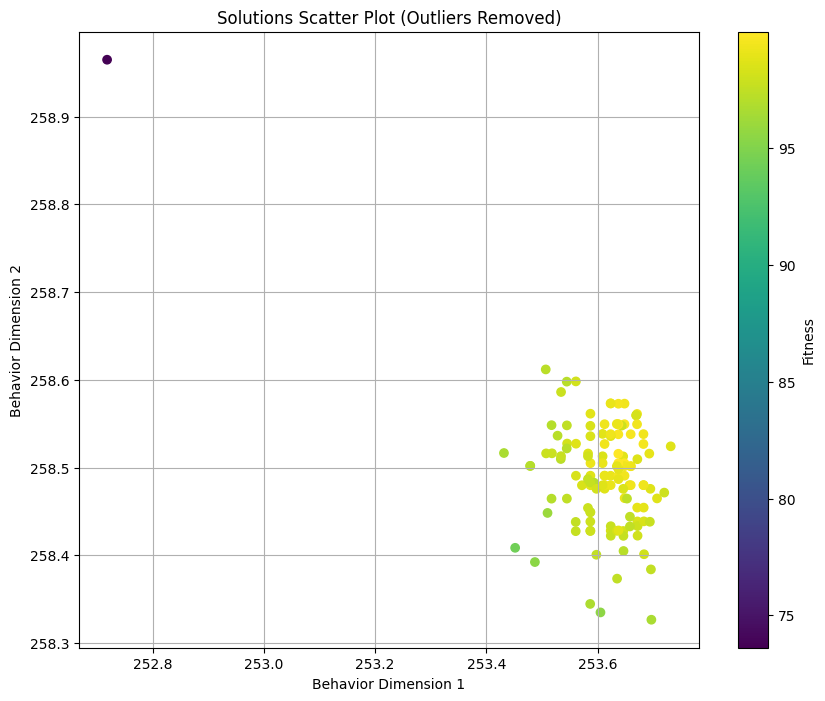

In [30]:
# Outlier Detection
q1 = np.percentile(descs, 25, axis=0)
q3 = np.percentile(descs, 75, axis=0)
iqr = q3 - q1
lower_bound = q1 - 500 * iqr
upper_bound = q3 + 500 * iqr

# A solution is an outlier if any of its descriptor dimensions are outside the bounds.
outlier_mask = np.any((descs < lower_bound) | (descs > upper_bound), axis=1)
inlier_mask = ~outlier_mask

# 3. Print Outliers
outlier_indices = np.where(outlier_mask)[0]
if len(outlier_indices) > 0:
    print("Detected Outliers:")
    for i in outlier_indices:
        print(f"  - Index: {i}, Fitness: {fits[i]:.2f}, Behavior: {descs[i]}")
else:
    print("No outliers detected.")


# 4. Filter Data for Plotting
# Use the inlier mask to select the data to be plotted.
fits_inliers = fits[inlier_mask]
descs_inliers = descs[inlier_mask]

# fits_inliers = fits
# descs_inliers = descs

# 5. Create the Scatter Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(descs_inliers[:, 0], descs_inliers[:, 1], c=fits_inliers, cmap='viridis')

# Add a colorbar to show the mapping of color to fitness
cbar = plt.colorbar(scatter)
cbar.set_label('Fitness')

# Add labels and title for clarity
plt.xlabel('Behavior Dimension 1')
plt.ylabel('Behavior Dimension 2')
plt.title('Solutions Scatter Plot (Outliers Removed)')
plt.grid(True)
plt.show()

Detected Outliers:
  - Index: 2, Fitness: 70.64, Behavior: [-84.62656 -22.50906]
  - Index: 6, Fitness: 96.76, Behavior: [219.75256 202.75772]
  - Index: 11, Fitness: 97.27, Behavior: [219.88348 202.61546]
  - Index: 14, Fitness: 97.23, Behavior: [219.74455 202.51868]
  - Index: 29, Fitness: 96.54, Behavior: [219.6913  202.49529]
  - Index: 31, Fitness: 96.46, Behavior: [219.68663 202.77225]
  - Index: 73, Fitness: 98.99, Behavior: [219.69664 202.80469]
  - Index: 75, Fitness: 97.56, Behavior: [219.93533 202.63086]
  - Index: 77, Fitness: 94.91, Behavior: [219.72504 202.80383]
  - Index: 81, Fitness: 97.27, Behavior: [219.77223 202.77304]
  - Index: 90, Fitness: 70.11, Behavior: [-84.67241  -22.641224]
  - Index: 94, Fitness: 71.58, Behavior: [-84.73143  -22.500114]
  - Index: 110, Fitness: 97.08, Behavior: [219.88278 202.70709]
  - Index: 117, Fitness: 98.20, Behavior: [219.76006 202.79016]


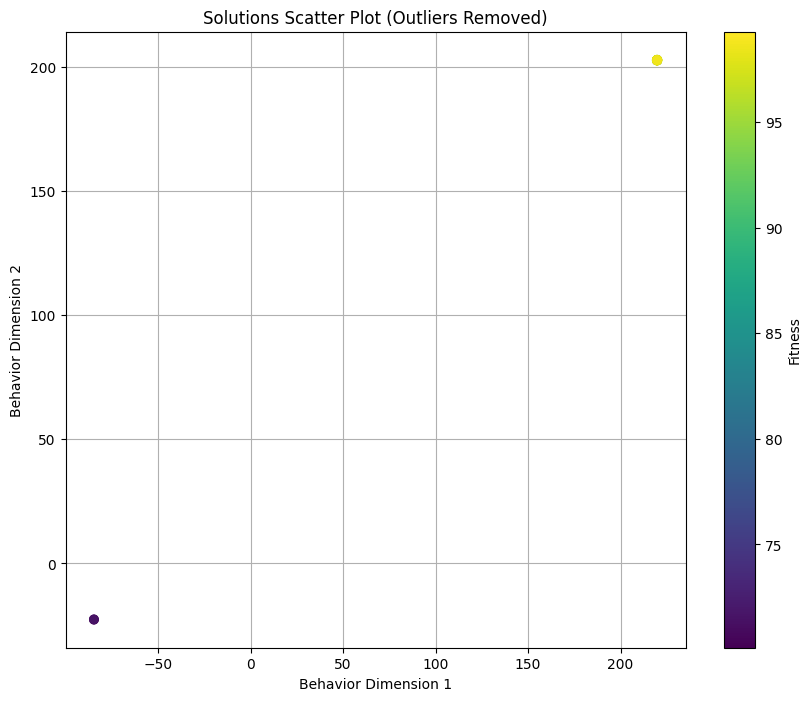

In [22]:
# Outlier Detection
q1 = np.percentile(descs, 25, axis=0)
q3 = np.percentile(descs, 75, axis=0)
iqr = q3 - q1
lower_bound = q1 - 2 * iqr
upper_bound = q3 + 2 * iqr

# A solution is an outlier if any of its descriptor dimensions are outside the bounds.
outlier_mask = np.any((descs < lower_bound) | (descs > upper_bound), axis=1)
inlier_mask = ~outlier_mask

# 3. Print Outliers
outlier_indices = np.where(outlier_mask)[0]
if len(outlier_indices) > 0:
    print("Detected Outliers:")
    for i in outlier_indices:
        print(f"  - Index: {i}, Fitness: {fits[i]:.2f}, Behavior: {descs[i]}")
else:
    print("No outliers detected.")


# 4. Filter Data for Plotting
# Use the inlier mask to select the data to be plotted.
# fits_inliers = fits[inlier_mask]
# descs_inliers = descs[inlier_mask]

fits_inliers = fits
descs_inliers = descs

# 5. Create the Scatter Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(descs_inliers[:, 0], descs_inliers[:, 1], c=fits_inliers, cmap='viridis')

# Add a colorbar to show the mapping of color to fitness
cbar = plt.colorbar(scatter)
cbar.set_label('Fitness')

# Add labels and title for clarity
plt.xlabel('Behavior Dimension 1')
plt.ylabel('Behavior Dimension 2')
plt.title('Solutions Scatter Plot (Outliers Removed)')
plt.grid(True)
plt.show()